# Modelo para predecir el rango de elección en el Draft

Importo librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

Cargo el dataset

In [2]:
ncaa = pd.read_csv('../../datos/procesados/ncaa_final.csv')

Ahora toca hacer la predicción de la target 'rango_pick'. Estamos hablando de 7 clases (ND, que son los no drafteados, y 6 rangos de elecciones). Aquí, dado que los ND son iguales que en la primera predicción, el desbalanceo es aún mayor.

In [3]:
print(ncaa['rango_pick'].value_counts(normalize=True).round(3))

rango_pick
ND       0.707
1-10     0.051
21-30    0.051
11-20    0.050
31-40    0.049
41-50    0.048
51-60    0.044
Name: proportion, dtype: float64


Preparo X e y, donde X son todas las columnas menos 'ronda' y 'rango_pick'. En X, hago un one hot encoding de la posicion. El dataframe y será solo la columna 'rango_pick', pero con un LabelEncoder.

In [4]:
# quito las columnas 'ronda' y 'rango_pick'
X = ncaa.drop(columns=['ronda', 'rango_pick'])

In [5]:
# hago un one hot encoding de la variable 'posicion'
X = pd.get_dummies(X, columns=['posicion'], drop_first=False)

In [6]:
# creo la variable de transformación y hago el encoding
le_target_eleccion = LabelEncoder()
y_enc = le_target_eleccion.fit_transform(ncaa['rango_pick'])

In [7]:
# imprimo las clases
print("Clases:", le_target_eleccion.classes_)

# Mostrar la distribución de los datos
print("Distribución:")
print(pd.Series(y_enc).value_counts(normalize=True).round(3))


Clases: ['1-10' '11-20' '21-30' '31-40' '41-50' '51-60' 'ND']
Distribución:
6    0.707
0    0.051
2    0.051
1    0.050
3    0.049
4    0.048
5    0.044
Name: proportion, dtype: float64


Divido el dataset en train y test para comenzar a entrenar el modelo

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, # utilizo X e y con encoding
    test_size=0.15,
    random_state=11,
    stratify=y_enc # se mantienen las mismas proporciones de clases en train y en test
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1802, 43)
(319, 43)
(1802,)
(319,)


## Modelo base

XGBoost multiclase con 7 clases. Punto de partida sin ajustes.

In [9]:
modelo = XGBClassifier(
    objective='multi:softmax', # devuelve directamente la clase ganadora
    num_class=7, # número de clases
    n_estimators=100, # número de árboles
    max_depth=4, # profundidad máxima de cada árbol
    learning_rate=0.1, # tasa de aprendizaje
    random_state=11, # semilla
    eval_metric='mlogloss' # métrica de evaluación (penaliza más los errores en los que 
                           # el modelo estaba muy seguro y se equivocó. Si el modelo dice "99% de que es ND"
                           # y resulta ser R1, el castigo es enorme. Si dice "55% ND" y falla, el castigo es pequeño)
)

modelo.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

## Evaluación del modelo base

Classification report y matriz de confusión.

In [10]:
y_pred = modelo.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le_target_eleccion.classes_))

              precision    recall  f1-score   support

        1-10       0.07      0.06      0.06        16
       11-20       0.00      0.00      0.00        16
       21-30       0.00      0.00      0.00        16
       31-40       0.11      0.06      0.08        16
       41-50       0.17      0.07      0.10        15
       51-60       0.33      0.14      0.20        14
          ND       0.79      0.97      0.87       226

    accuracy                           0.70       319
   macro avg       0.21      0.19      0.19       319
weighted avg       0.59      0.70      0.64       319



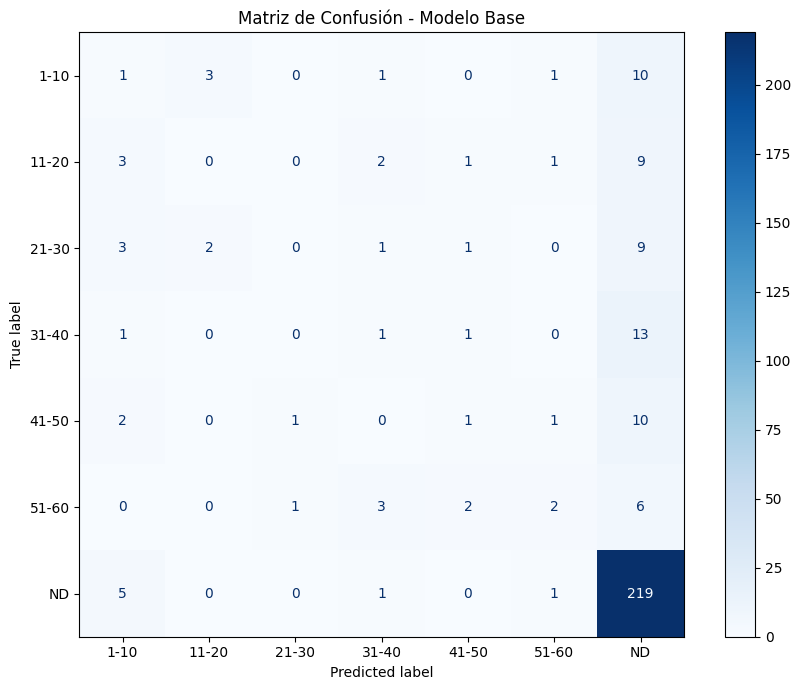

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_target_eleccion.classes_)
fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión - Modelo Base')
plt.tight_layout()
plt.show()

## Modelo balanceado

El desbalanceo aquí es más extremo (ND = 70%). Aplico pesos por clase
para que el modelo preste más atención a los rangos drafteados.

In [12]:
# pesos iguales para todas las clases
pesos = compute_sample_weight(class_weight='balanced', y=y_train)

modelo_v2 = XGBClassifier(
    objective='multi:softmax',
    num_class=7,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

# entreno el modelo con pesos iguales
modelo_v2.fit(X_train, y_train, sample_weight=pesos)

y_pred_v2 = modelo_v2.predict(X_test)

print(classification_report(y_test, y_pred_v2, target_names=le_target_eleccion.classes_))

              precision    recall  f1-score   support

        1-10       0.17      0.25      0.20        16
       11-20       0.11      0.12      0.12        16
       21-30       0.00      0.00      0.00        16
       31-40       0.05      0.06      0.06        16
       41-50       0.18      0.13      0.15        15
       51-60       0.31      0.36      0.33        14
          ND       0.86      0.82      0.84       226

    accuracy                           0.63       319
   macro avg       0.24      0.25      0.24       319
weighted avg       0.65      0.63      0.64       319



El modelo tiene un problema claro: sabe decir "ND" pero no sabe distinguir entre rangos de pick.
El único que funciona bien es ND — precision 0.86, recall 0.82, f1 0.84. Cuando el modelo dice que un jugador no será drafteado, acierta el 86% de las veces, y de todos los ND reales encuentra el 82%.
Para el resto de rangos los números son muy bajos. El peor es 21-30 con f1 de 0.00 — el modelo no identificó correctamente ni un solo jugador de ese rango. El mejor de los rangos drafteados es 51-60 con f1 de 0.33, que sigue siendo malo.
El macro avg f1 de 0.24 es la foto real: si tratamos todas las clases igual, el modelo apenas supera el azar. El weighted avg de 0.64 parece mejor pero está inflado por el peso enorme de ND (226 de 319 jugadores).
La causa es el desbalanceo extremo — hay 226 ND pero solo 14-16 jugadores por rango de pick. Con tan pocos ejemplos por clase el modelo no aprende a diferenciarlos.

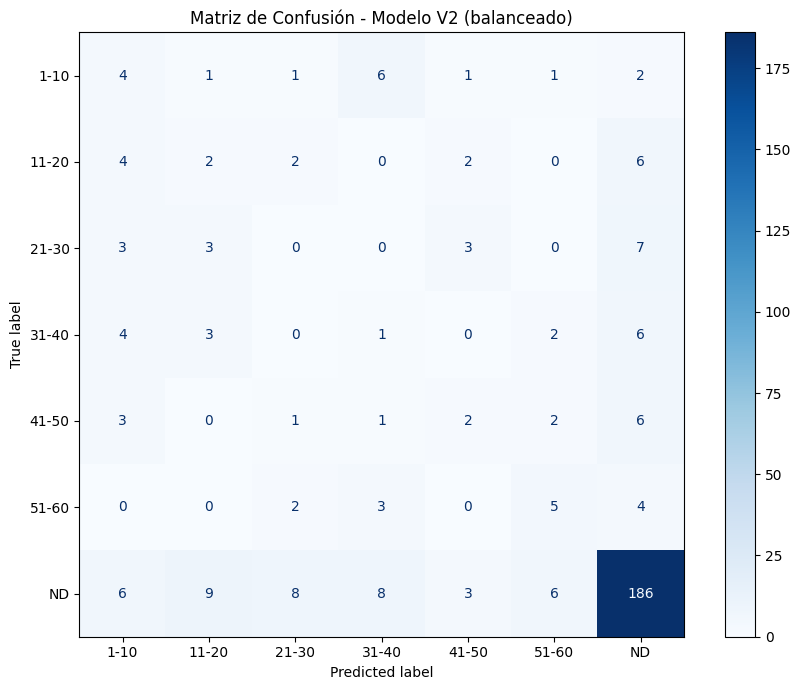

In [13]:
cm2 = confusion_matrix(y_test, y_pred_v2)
disp2 = ConfusionMatrixDisplay(cm2, display_labels=le_target_eleccion.classes_)
fig, ax = plt.subplots(figsize=(9, 7))
disp2.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión - Modelo V2 (balanceado)')
plt.tight_layout()
plt.show()

* FILA 1-10 — jugadores que realmente fueron elegidos entre los picks 1 y 10. Había 16 en total.

    * 4 → dijo 1-10 ✅ acertó
    * 1 → dijo 11-20 ❌ falso negativo — se perdió un top 10
    * 1 → dijo 21-30 ❌ falso negativo
    * 6 → dijo 31-40 ❌ falso negativo — los mandó a la segunda mitad del draft
    * 1 → dijo 41-50 ❌ falso negativo
    * 1 → dijo 51-60 ❌ falso negativo
    * 2 → dijo ND ❌ falso negativo — descartó 2 jugadores de lotería

    De 16 jugadores top 10, solo encontró 4. Los otros 12 los dispersó por todos los rangos.

* FILA 11-20 — jugadores elegidos entre los picks 11 y 20. Había 16 en total.

    * 4 → dijo 1-10 ❌ los sobreestimó, los subió demasiado arriba
    * 2 → dijo 11-20 ✅ acertó
    * 2 → dijo 21-30 ❌ falso negativo
    * 0 → dijo 31-40
    * 2 → dijo 41-50 ❌ falso negativo
    * 0 → dijo 51-60
    * 6 → dijo ND ❌ falso negativo — descartó 6 jugadores de primera ronda

    De 16 jugadores, solo acertó 2. La mayoría acabó en ND o en rangos equivocados.

* FILA 21-30 — jugadores elegidos entre los picks 21 y 30. Había 16 en total.

    * 3 → dijo 1-10 ❌ los sobreestimó
    * 3 → dijo 11-20 ❌ falso negativo
    * 0 → dijo 21-30 ❌ cero aciertos
    * 0 → dijo 31-40
    * 3 → dijo 41-50 ❌ falso negativo
    * 0 → dijo 51-60
    * 7 → dijo ND ❌ falso negativo — casi la mitad descartados

    El peor de todos. Ni un solo acierto. El modelo no tiene ni idea de dónde colocar a estos jugadores.

* FILA 31-40 — jugadores elegidos entre los picks 31 y 40. Había 16 en total.

    * 4 → dijo 1-10 ❌ los sobreestimó mucho
    * 3 → dijo 11-20 ❌ falso negativo
    * 0 → dijo 21-30
    * 1 → dijo 31-40 ✅ acertó
    * 0 → dijo 41-50
    * 2 → dijo 51-60 ❌ falso negativo
    * 6 → dijo ND ❌ falso negativo

    De 16 jugadores, solo acertó 1. Y además mandó 4 al top 10, que es el error opuesto — los sobreestimó completamente.

* FILA 41-50 — jugadores elegidos entre los picks 41 y 50. Había 15 en total.

    * 3 → dijo 1-10 ❌ los sobreestimó
    * 0 → dijo 11-20
    * 1 → dijo 21-30 ❌ falso negativo
    * 1 → dijo 31-40 ❌ falso negativo
    * 2 → dijo 41-50 ✅ acertó
    * 2 → dijo 51-60 ❌ falso negativo
    * 6 → dijo ND ❌ falso negativo

    De 15 jugadores, solo acertó 2. Sigue el mismo patrón — muchos mandados a ND y algunos sobreestimados al top 10.

* FILA 51-60 — jugadores elegidos entre los picks 51 y 60. Había 14 en total.

    * 0 → dijo 1-10
    * 0 → dijo 11-20
    * 2 → dijo 21-30 ❌ los sobreestimó
    * 3 → dijo 31-40 ❌ falso negativo
    * 0 → dijo 41-50
    * 5 → dijo 51-60 ✅ acertó
    * 4 → dijo ND ❌ falso negativo

    De 14 jugadores, acertó 5. Es el mejor rango drafteado del modelo, probablemente porque los jugadores de picks bajos tienen stats más modestas y el modelo los diferencia mejor de los top picks.

* FILA ND — jugadores que realmente no fueron drafteados. Había 226 en total.

    * 6 → dijo 1-10 ❌ falso positivo — se inventó 6 talentos de lotería que no existían
    * 9 → dijo 11-20 ❌ falso positivo
    * 8 → dijo 21-30 ❌ falso positivo
    * 8 → dijo 31-40 ❌ falso positivo
    * 3 → dijo 41-50 ❌ falso positivo
    * 6 → dijo 51-60 ❌ falso positivo
    * 186 → dijo ND ✅ acertó

    De 226 jugadores no drafteados, acertó 186. Mandó 40 a rangos de pick equivocados — alarmas falsas repartidas por todos los rangos.

* Resumen: el modelo solo sabe decir "este no vale" con cierta fiabilidad. Para los 93 jugadores drafteados reales (16+16+16+16+15+14), solo acertó el rango exacto en 14 casos. Es como si fuese un ojeador que no sabe distinguir una joya de segunda ronda de un jugador de primeras posiciones.

## Evaluación con AUC-ROC

Mismo enfoque que en el modelo de ronda pero con **7 clases** en vez de 3. El AUC-ROC macro calcula la media del score de cada clase contra el resto.

Con 7 clases muy desbalanceadas (ND = 70%) el AUC-ROC macro es más informativo que el accuracy — penaliza más los errores en las clases minoritarias.

AUC-ROC macro: 0.7470



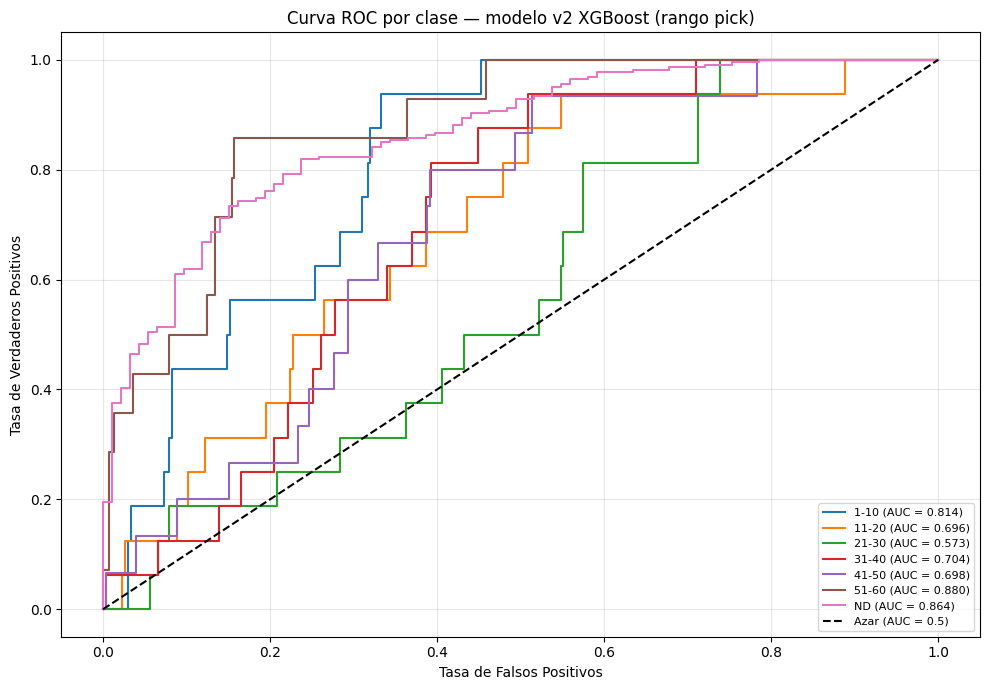

In [14]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# binarizo el test para calcular AUC-ROC por clase
n_clases = len(le_target_eleccion.classes_)
y_test_bin = label_binarize(y_test, classes=list(range(n_clases)))

# obtengo probabilidades del modelo v2
probs_v2 = modelo_v2.predict_proba(X_test)

# calculo AUC-ROC macro
auc_macro = roc_auc_score(y_test_bin, probs_v2, multi_class='ovr', average='macro')
print(f'AUC-ROC macro: {auc_macro:.4f}')
print()

# pinto la curva ROC de cada clase
fig, ax = plt.subplots(figsize=(10, 7))
colores = plt.cm.tab10.colors

for i, clase in enumerate(le_target_eleccion.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs_v2[:, i])
    auc = roc_auc_score(y_test_bin[:, i], probs_v2[:, i])
    ax.plot(fpr, tpr, color=colores[i], label=f'{clase} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.5)')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curva ROC por clase — modelo v2 XGBoost (rango pick)')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretación

Aquí destaca que del 51-60 (0.880) y ND (0.864) son los más fáciles. Los picks del final de la segunda ronda tienen un perfil estadístico bastante reconocible para el modelo, ya que son jugadores con números decentes, pero no espectaculares. Y los no drafteados siguen siendo los más fáciles de identificar.

El desastre es 21-30 (0.573). Eso es prácticamente azar. 

1-10 (0.814) funciona bien.

11-20 (0.696) y 41-50 (0.698) están en zona media-baja, lo que también es coherente: son rangos donde la diferencia entre jugadores es pequeña.

## Guardo el modelo

In [16]:
os.makedirs('../pkl/modelos', exist_ok=True)
os.makedirs('../pkl/preprocesado', exist_ok=True)

joblib.dump(modelo_v2, '../pkl/modelos/xgb_rango_balanceado.pkl')
joblib.dump(le_target_eleccion, '../pkl/preprocesado/le_rango.pkl')

print("Modelo guardado")

Modelo guardado


## Predicción con jugador real

Busco el jugador en el raw por nombre y año, cruzo con los datos procesados
por stats únicas, y predigo con probabilidades.

In [15]:
raw = pd.read_csv('../../datos/raw/College_BasketballPlayers2009-2021.csv', low_memory=False)
ncaa_final = pd.read_csv('../../datos/procesados/ncaa_final.csv')

jugador_nombre = 'Cade Cunningham'
anio = 2021

jugador_raw = raw[(raw['player_name'] == jugador_nombre) & (raw['year'] == anio)].iloc[0]

mask = (
    (ncaa_final['pts'].round(4) == round(jugador_raw['pts'], 4)) &
    (ncaa_final['treb'].round(4) == round(jugador_raw['treb'], 4)) &
    (ncaa_final['ast'].round(4) == round(jugador_raw['ast'], 4))
)
jugador_procesado = ncaa_final[mask]

X_jugador = jugador_procesado.drop(columns=['ronda', 'rango_pick'])
X_jugador = pd.get_dummies(X_jugador, columns=['posicion'])
X_jugador = X_jugador.reindex(columns=X_train.columns, fill_value=0)

probs = modelo_v2.predict_proba(X_jugador)[0]

print(f"Predicción para {jugador_nombre} ({anio}):")
print("-"*40)
for clase, prob in zip(le_target_eleccion.classes_, probs):
    print(f"  {clase}: {prob*100:.1f}%")

pick = jugador_raw['pick']
if pd.isna(pick):
    rango_real = 'ND'
elif pick <= 10:
    rango_real = '1-10'
elif pick <= 20:
    rango_real = '11-20'
elif pick <= 30:
    rango_real = '21-30'
elif pick <= 40:
    rango_real = '31-40'
elif pick <= 50:
    rango_real = '41-50'
else:
    rango_real = '51-60'

print(f"\nRealidad: Pick #{int(pick)} → {rango_real}")

Predicción para Cade Cunningham (2021):
----------------------------------------
  1-10: 84.0%
  11-20: 3.7%
  21-30: 1.6%
  31-40: 1.2%
  41-50: 5.6%
  51-60: 1.1%
  ND: 2.9%

Realidad: Pick #1 → 1-10


In [16]:
raw = pd.read_csv('../../datos/raw/College_BasketballPlayers2009-2021.csv', low_memory=False)
ncaa_final = pd.read_csv('../../datos/procesados/ncaa_final.csv')

jugador_nombre = 'Luka Garza'
anio = 2021

jugador_raw = raw[(raw['player_name'] == jugador_nombre) & (raw['year'] == anio)].iloc[0]

mask = (
    (ncaa_final['pts'].round(4) == round(jugador_raw['pts'], 4)) &
    (ncaa_final['treb'].round(4) == round(jugador_raw['treb'], 4)) &
    (ncaa_final['ast'].round(4) == round(jugador_raw['ast'], 4))
)
jugador_procesado = ncaa_final[mask]

X_jugador = jugador_procesado.drop(columns=['ronda', 'rango_pick'])
X_jugador = pd.get_dummies(X_jugador, columns=['posicion'])
X_jugador = X_jugador.reindex(columns=X_train.columns, fill_value=0)

probs = modelo_v2.predict_proba(X_jugador)[0]

print(f"Predicción para {jugador_nombre} ({anio}):")
print("-"*35)
for clase, prob in zip(le_target_eleccion.classes_, probs):
    print(f"  {clase}: {prob*100:.1f}%")

pick = jugador_raw['pick']
if pd.isna(pick):
    rango_real = 'ND'
elif pick <= 10:
    rango_real = '1-10'
elif pick <= 20:
    rango_real = '11-20'
elif pick <= 30:
    rango_real = '21-30'
elif pick <= 40:
    rango_real = '31-40'
elif pick <= 50:
    rango_real = '41-50'
else:
    rango_real = '51-60'

print(f"\nRealidad: Pick #{int(pick)} → {rango_real}")


Predicción para Luka Garza (2021):
-----------------------------------
  1-10: 4.0%
  11-20: 2.9%
  21-30: 2.4%
  31-40: 3.3%
  41-50: 3.2%
  51-60: 82.9%
  ND: 1.3%

Realidad: Pick #52 → 51-60


In [17]:
raw = pd.read_csv('../../datos/raw/College_BasketballPlayers2009-2021.csv', low_memory=False)
ncaa_final = pd.read_csv('../../datos/procesados/ncaa_final.csv')

jugador_nombre = 'Santi Aldama'
anio = 2021

jugador_raw = raw[(raw['player_name'] == jugador_nombre) & (raw['year'] == anio)].iloc[0]

mask = (
    (ncaa_final['pts'].round(4) == round(jugador_raw['pts'], 4)) &
    (ncaa_final['treb'].round(4) == round(jugador_raw['treb'], 4)) &
    (ncaa_final['ast'].round(4) == round(jugador_raw['ast'], 4))
)
jugador_procesado = ncaa_final[mask]

X_jugador = jugador_procesado.drop(columns=['ronda', 'rango_pick'])
X_jugador = pd.get_dummies(X_jugador, columns=['posicion'])
X_jugador = X_jugador.reindex(columns=X_train.columns, fill_value=0)

probs = modelo_v2.predict_proba(X_jugador)[0]

print(f"Predicción para {jugador_nombre} ({anio}):")
print("-"*35)
for clase, prob in zip(le_target_eleccion.classes_, probs):
    print(f"  {clase}: {prob*100:.1f}%")

pick = jugador_raw['pick']
if pd.isna(pick):
    rango_real = 'ND'
elif pick <= 10:
    rango_real = '1-10'
elif pick <= 20:
    rango_real = '11-20'
elif pick <= 30:
    rango_real = '21-30'
elif pick <= 40:
    rango_real = '31-40'
elif pick <= 50:
    rango_real = '41-50'
else:
    rango_real = '51-60'

print(f"\nRealidad: Pick #{int(pick)} → {rango_real}")


Predicción para Santi Aldama (2021):
-----------------------------------
  1-10: 1.4%
  11-20: 3.0%
  21-30: 82.2%
  31-40: 5.3%
  41-50: 1.2%
  51-60: 1.2%
  ND: 5.8%

Realidad: Pick #30 → 21-30


In [18]:
nombre_jugador = 'Roberto Cantero'

pts  = 22.3
treb = 6.1
ast  = 8.2

# construyo el dataframe base con todas las columnas del modelo a 0
X_manual = pd.DataFrame(0, index=[0], columns=X_train.columns)

# relleno solo las tres stats
X_manual['pts']  = pts
X_manual['treb'] = treb
X_manual['ast']  = ast

# predicción
probs = modelo_v2.predict_proba(X_manual)[0]

print(f"\nPredicción manual para {nombre_jugador}:")
print("-"*40)
for clase, prob in zip(le_target_eleccion.classes_, probs):
    print(f"  {clase:>6}  {prob*100:5.1f}%")


Predicción manual para Roberto Cantero:
----------------------------------------
    1-10    3.5%
   11-20    2.0%
   21-30    3.1%
   31-40    1.6%
   41-50   79.9%
   51-60    4.7%
      ND    5.2%
